In [25]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")
from src import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
checkpoints = {
    "dft1d_15": "20251118-1205-synthetic_deepcad_15",
    "dft1d_150": "20251118-1221-synthetic_deepcad_150",
    "dct3d_15": "20251202-0738-synthetic_deepcad_15",
    "dct3d_150": "20251202-0835-synthetic_deepcad_150",
}

In [27]:
dataset = "zebrafish"
max_frames = 300
variant = "_30"
avg_win = None
method = "dft1d_150"
checkpoint = checkpoints[method]

x = Recording(f"dataset/{dataset}/x.tif", norm=True, max_frames=max_frames)
deepcad = Recording(f"dataset/{dataset}/deepcad{variant}.tif", norm=True, max_frames=max_frames)
gt = Recording(f"dataset/{dataset}/gt.tif", norm=True, max_frames=max_frames)
f2c_grid = Recording(f"results/{dataset}/deepcad{variant}{avg_win or ''}/grid_{method.split("_")[0]}.tiff", max_frames=max_frames)
f2c_net = Recording(f"results/{dataset}/deepcad{variant}{avg_win or ''}/{checkpoint}.tiff", max_frames=max_frames)

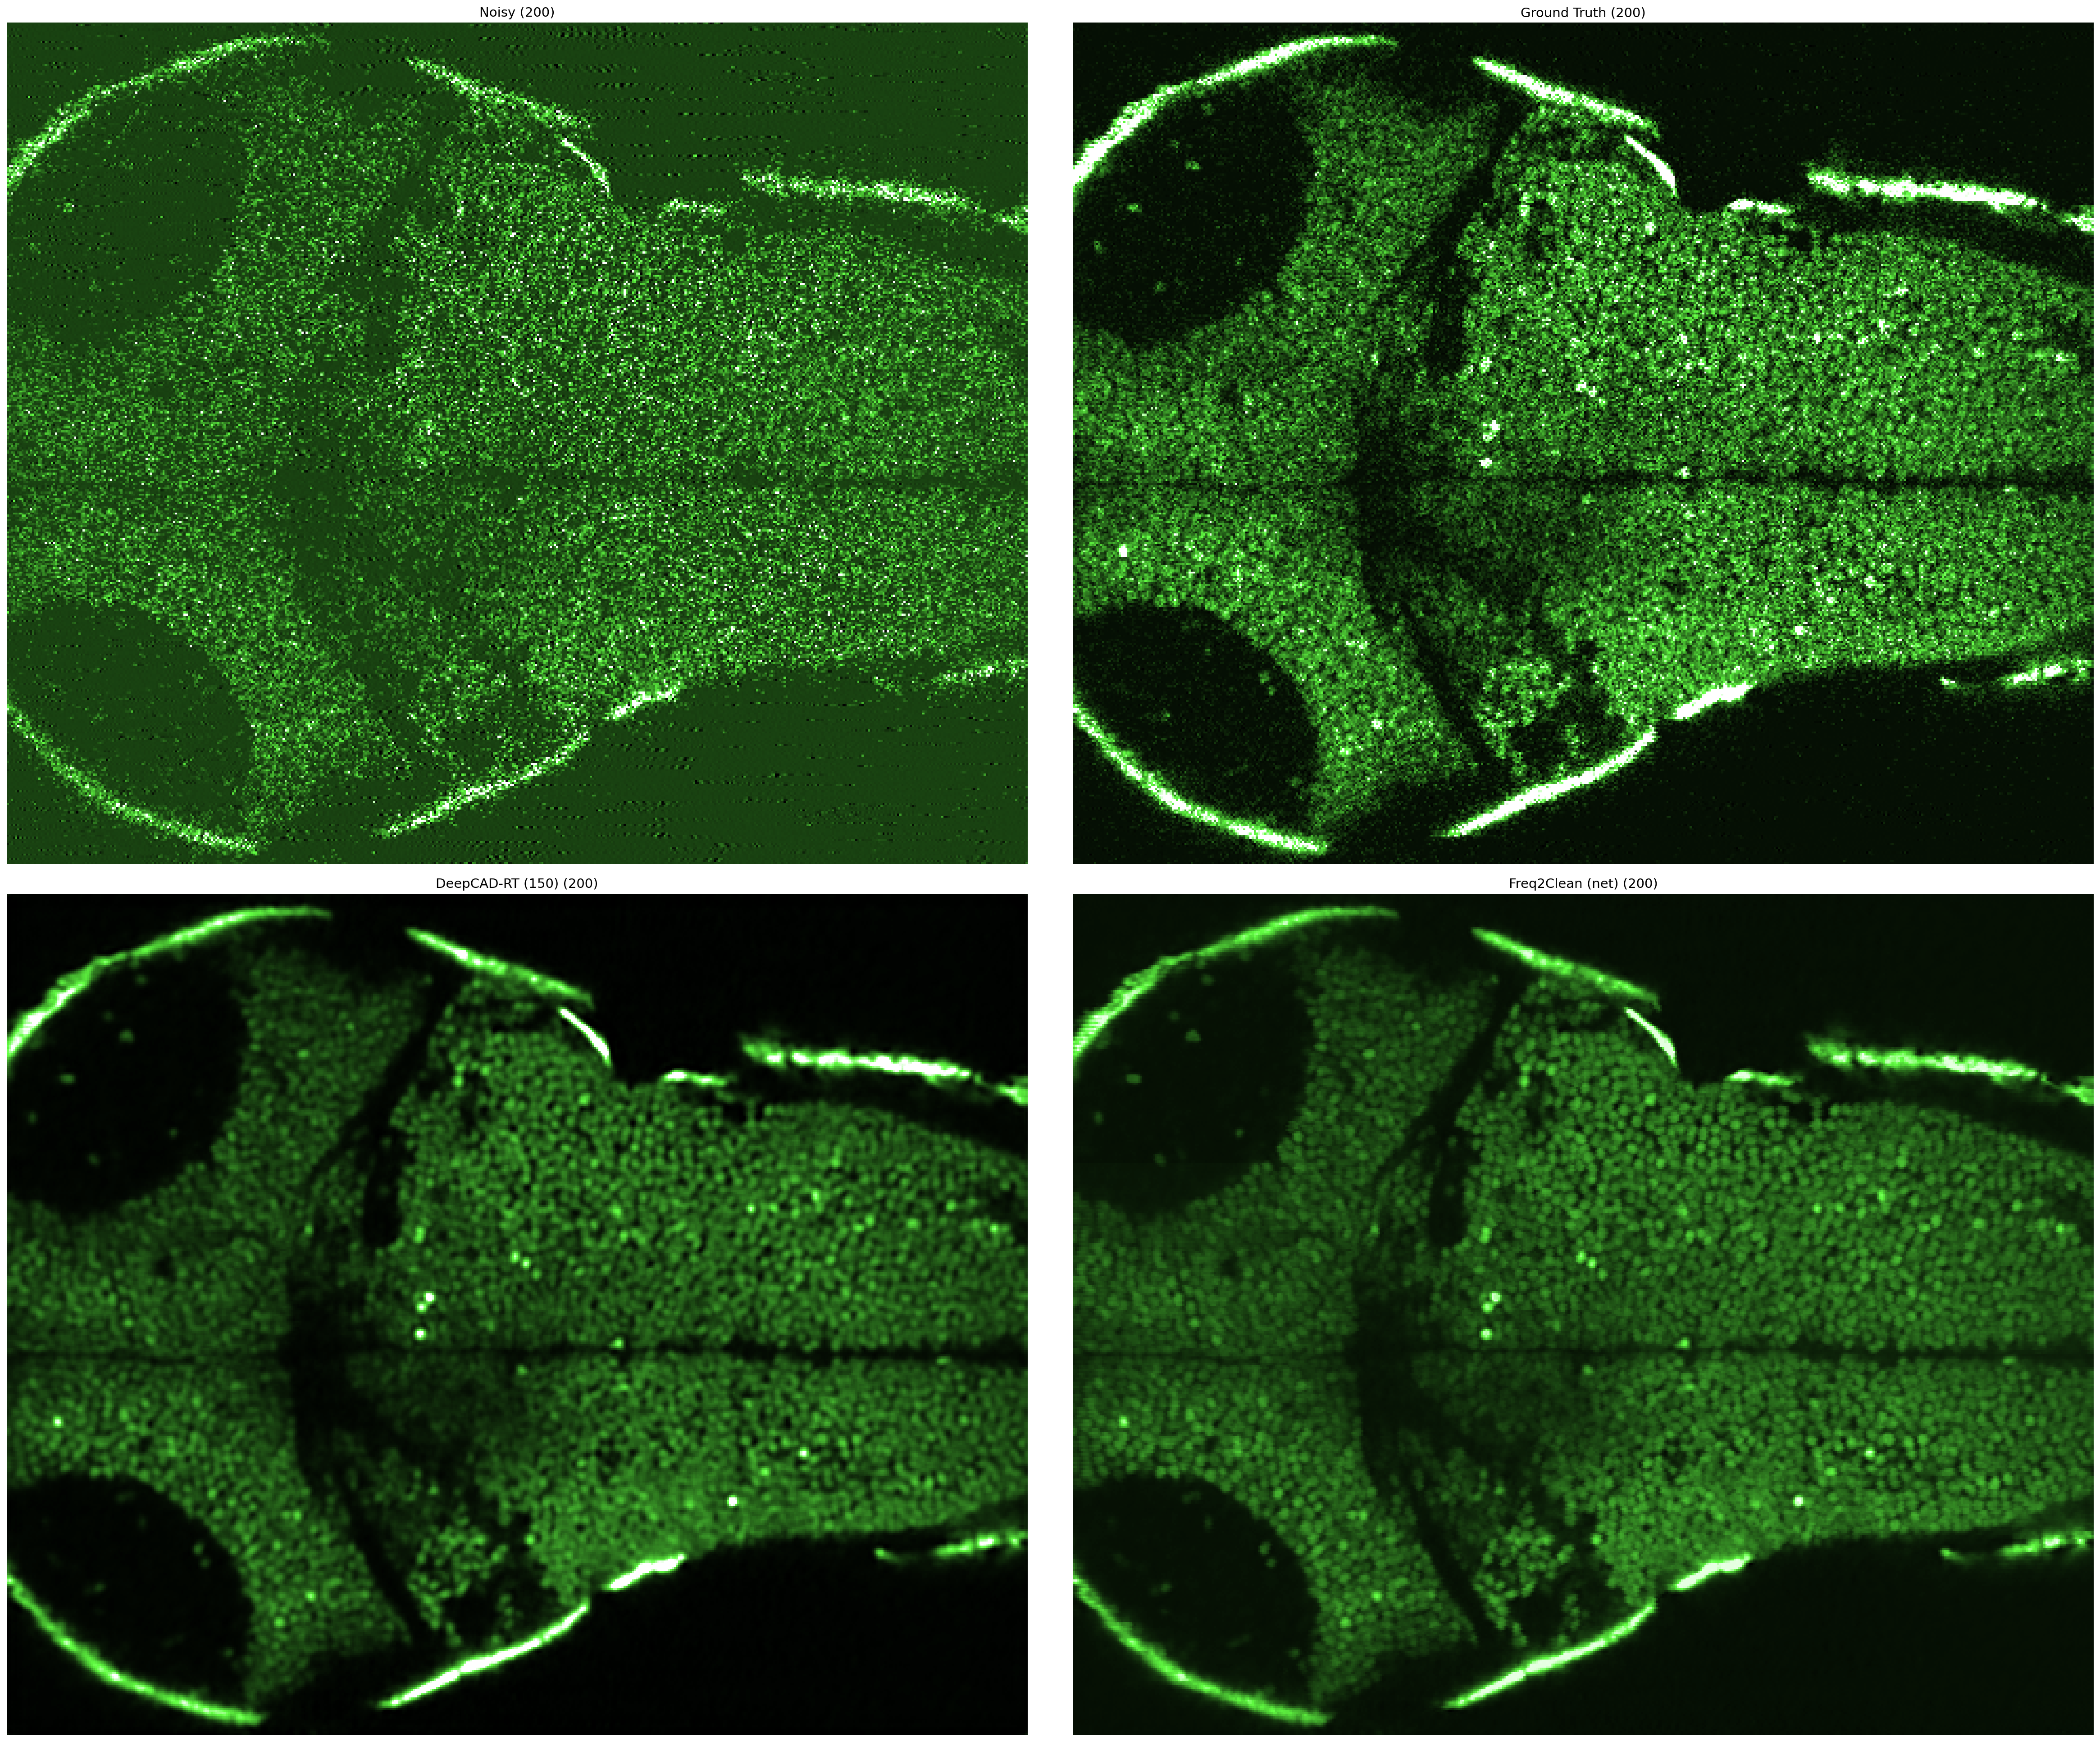

In [30]:
i = 200
imshow(
    {
        f"Noisy ({i})": x.np[i],
        f"Ground Truth ({i})": gt.np[i],
        f"DeepCAD-RT (150) ({i})": deepcad.np[i],
        # f"Freq2Clean (grid) ({i})": f2c_grid.np[i],
        f"Freq2Clean (net) ({i})": f2c_net.np[i],
    },
    size=16,
    cols=2,
    zoom=1
)

In [15]:
deepcad.render(f"deepcad{variant}.mp4", bitrate=6_000)
f2c_grid.render(f"f2c_grid_{method}{variant}.mp4", bitrate=6_000)
f2c_net.render(f"f2c_net_{method}{variant}.mp4", bitrate=6_000)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (485, 400) to (496, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
x265 [info]: HEVC encoder version 3.5+1-f0c1022b6
x265 [info]: build info [Linux][GCC 8.3.0][64 bit] 8bit+10bit+12bit
x265 [info]: using cpu capabilities: MMX2 SSE2Fast LZCNT SSSE3 SSE4.2 AVX FMA3 BMI2 AVX2
x265 [info]: Main profile, Level-3 (Main tier)
x265 [info]: Thread pool created using 24 threads
x265 [info]: Slices                              : 1
x265 [info]: frame threads / pool features       : 4 / wpp(7 rows)
x265 [warning]: Source height < 720p; disabling lookahead-slices
x265 [info]: Coding QT: max CU size, min CU size : 64 / 8
x265 [info]: Residual QT: max TU size, max depth : 32 / 1 inter / 1 intra
x265 [info]: ME / range / subpel / merge         : hex / 57

In [16]:
Editor().make_green(f"deepcad{variant}.mp4", bitrate=6_000)
Editor().make_green(f"f2c_grid_{method}{variant}.mp4", bitrate=6_000)
Editor().make_green(f"f2c_net_{method}{variant}.mp4", bitrate=6_000)

Moviepy - Building video tmp.mp4.
Moviepy - Writing video tmp.mp4



Moviepy - Done !
Moviepy - video ready tmp.mp4
Moviepy - Building video tmp.mp4.
Moviepy - Writing video tmp.mp4



Moviepy - Done !
Moviepy - video ready tmp.mp4
Moviepy - Building video tmp.mp4.
Moviepy - Writing video tmp.mp4



Moviepy - Done !
Moviepy - video ready tmp.mp4


In [17]:
Editor().alternate(
    {
        f"DeepCAD-RT ({variant[1:]})": f"deepcad{variant}.mp4",
        f"Freq2Clean (net)": f"f2c_net_{method}{variant}.mp4",
    },
    bitrate=6_000,
    output=f"deepcad_vs_freq2clean_net_{method}{variant}.mp4",
)

Moviepy - Building video deepcad_vs_freq2clean_net_dft1d_15_10.mp4.
Moviepy - Writing video deepcad_vs_freq2clean_net_dft1d_15_10.mp4



Moviepy - Done !
Moviepy - video ready deepcad_vs_freq2clean_net_dft1d_15_10.mp4
